# NB 1 - Data Cleaning

In [18]:
# Import the libraries
import pandas as pd
import numpy as np

In [19]:
# Load the dataset
df = pd.read_csv("C:/Projects/13_Waste_to_energy_Analytics_Platform/data/waste_management.csv")
df.head()

,Countries,Total collected MSW (t),Food,Garden,Paper,Plastic,Glass,Metal,Rubber and Leather,Textile,Other,Scenario,CO₂ emissions reduction potential
0,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Compost organics,-0.468069
1,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Digest organics,-0.468069
2,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Retrofit landfill,-0.463089
3,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Half waste,-0.500000
4,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Compost + retrofit,-0.674354


In [20]:
# Quick check
df.shape

(344, 13)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Countries                          344 non-null    object 
 1   Total collected MSW (t)            344 non-null    float64
 2   Food                               344 non-null    float64
 3   Garden                             344 non-null    float64
 4   Paper                              344 non-null    float64
 5   Plastic                            344 non-null    float64
 6   Glass                              344 non-null    float64
 7   Metal                              344 non-null    float64
 8   Rubber and Leather                 344 non-null    float64
 9   Textile                            344 non-null    float64
 10  Other                              344 non-null    float64
 11  Scenario                           344 non-null    object 

In [22]:
df.describe()

,Total collected MSW (t),Food,Garden,Paper,Plastic,Glass,Metal,Rubber and Leather,Textile,Other,CO₂ emissions reduction potential
count,3.440000e+02,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000
mean,3.082937e+07,46.658414,3.914358,13.709583,11.787763,3.973372,3.144018,0.977191,1.086512,14.748550,-0.474485
std,4.993404e+07,15.537715,5.088981,7.346504,4.672722,3.182334,3.134707,2.186811,2.316937,8.720785,0.220279
min,2.414125e+06,13.382785,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,-0.878647
25%,8.849403e+06,34.434434,0.000000,8.500000,9.000000,2.147783,1.110000,0.000000,0.000000,6.600000,-0.637848
50%,1.354213e+07,49.860000,1.785356,12.000000,11.065990,3.050000,2.857143,0.000000,0.000000,15.000000,-0.500000
75%,3.072659e+07,56.000000,5.220000,18.900000,13.700000,5.000000,4.000000,1.000000,1.000000,21.520000,-0.312225
max,2.717482e+08,77.700000,18.300000,34.610000,23.000000,16.820000,19.380000,12.600000,10.000000,44.791506,0.000000


In [ ]:
# 1. Check for missing values
df.isnull().sum()

Countries                            0
Total collected MSW (t)              0
Food                                 0
Garden                               0
Paper                                0
Plastic                              0
Glass                                0
Metal                                0
Rubber and Leather                   0
Textile                              0
Other                                0
Scenario                             0
CO₂ emissions reduction potential    0
dtype: int64

In [ ]:
# 2. Explore data quality
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
339    False
340    False
341    False
342    False
343    False
Length: 344, dtype: bool

In [25]:
# Check the data types
df.dtypes

Countries                             object
Total collected MSW (t)              float64
Food                                 float64
Garden                               float64
Paper                                float64
Plastic                              float64
Glass                                float64
Metal                                float64
Rubber and Leather                   float64
Textile                              float64
Other                                float64
Scenario                              object
CO₂ emissions reduction potential    float64
dtype: object

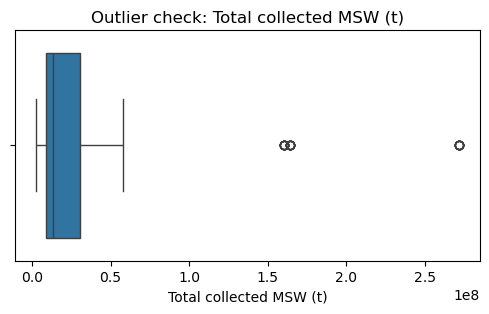

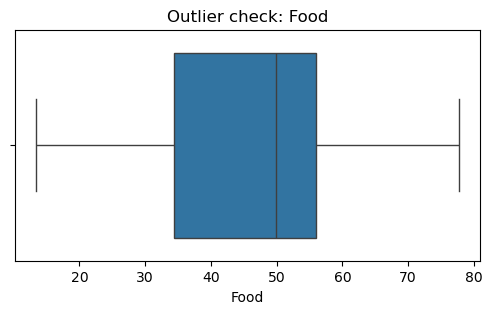

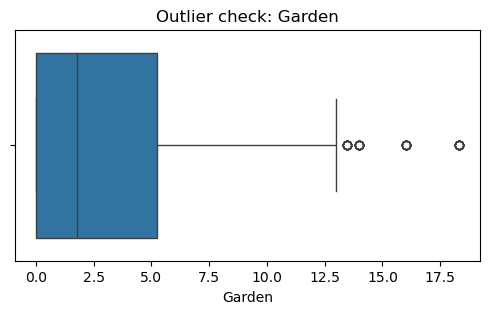

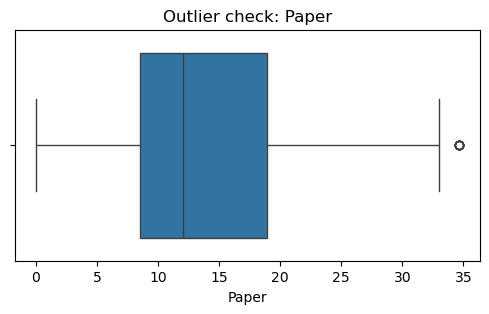

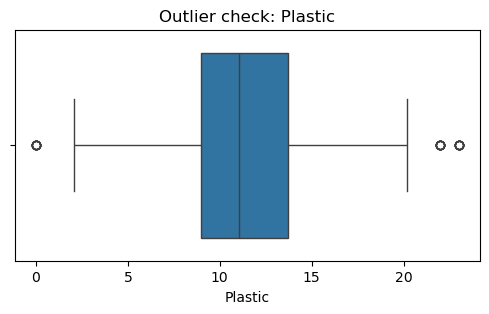

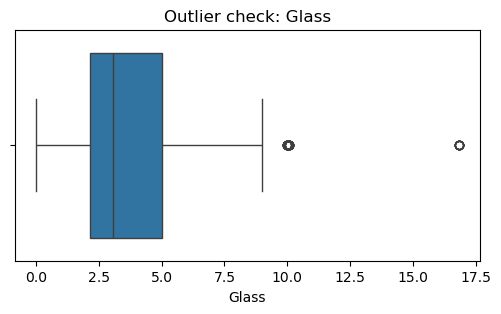

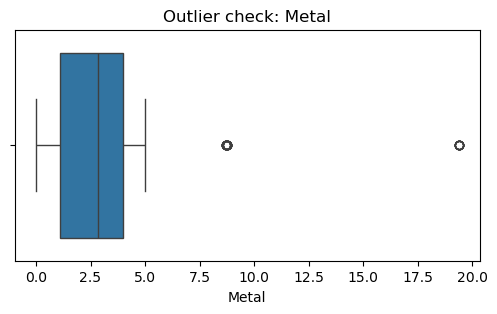

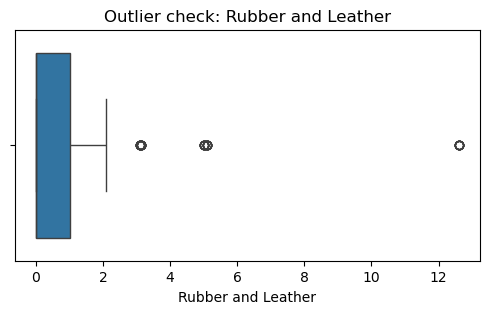

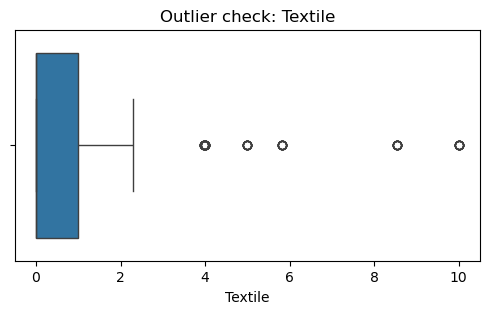

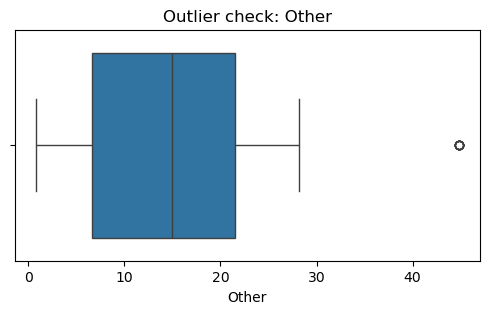

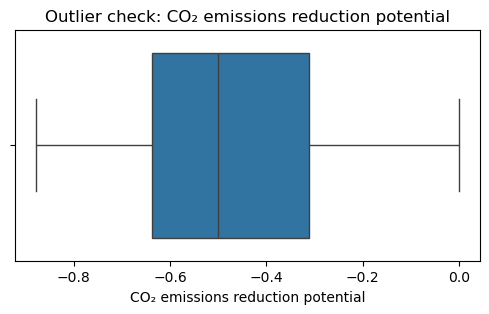

In [26]:
# Checking the outliers
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["Total collected MSW (t)", "Food", "Garden", "Paper", 
                "Plastic", "Glass", "Metal", "Rubber and Leather", 
                "Textile", "Other", "CO₂ emissions reduction potential"]

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier check: {col}")
    plt.show()

In [27]:
# Identify rows where any value is an outlier
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# This finds rows that are "extreme"
outlier_mask = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))

# Show me the rows that have at least one outlier
outlier_rows = df[outlier_mask.any(axis=1)]
print(outlier_rows)

         Countries  Total collected MSW (t)   Food  Garden  Paper  Plastic  \
0          Algeria             9.372439e+06  54.40     1.5   9.80     16.9   
1          Algeria             9.372439e+06  54.40     1.5   9.80     16.9   
2          Algeria             9.372439e+06  54.40     1.5   9.80     16.9   
3          Algeria             9.372439e+06  54.40     1.5   9.80     16.9   
4          Algeria             9.372439e+06  54.40     1.5   9.80     16.9   
..             ...                      ...    ...     ...    ...      ...   
323  United States             2.717482e+08  21.59    18.3  23.05     12.2   
324  United States             2.717482e+08  21.59    18.3  23.05     12.2   
325  United States             2.717482e+08  21.59    18.3  23.05     12.2   
326  United States             2.717482e+08  21.59    18.3  23.05     12.2   
327  United States             2.717482e+08  21.59    18.3  23.05     12.2   

     Glass  Metal  Rubber and Leather  Textile  Other          

In [28]:
# Check how many times 'Algeria' appears in your dataset
print(df[df['Countries'] == 'Algeria'].shape)

(8, 13)


WE cannot remove the outliers because these outliers are unique.

In [29]:
# Check the negative Values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(col, (df[col] < 0).sum())

Total collected MSW (t) 0
Food 0
Garden 0
Paper 0
Plastic 0
Glass 0
Metal 0
Rubber and Leather 0
Textile 0
Other 0
CO₂ emissions reduction potential 336


In [30]:
# Check for rows where CO2 reduction potential is negative
negative_co2 = df[df['CO₂ emissions reduction potential'] < 0]

# Print the first few rows to see the 'Scenario' and 'Country'
print(negative_co2[['Countries', 'Scenario', 'CO₂ emissions reduction potential']])

    Countries            Scenario  CO₂ emissions reduction potential
0     Algeria    Compost organics                          -0.468069
1     Algeria     Digest organics                          -0.468069
2     Algeria   Retrofit landfill                          -0.463089
3     Algeria          Half waste                          -0.500000
4     Algeria  Compost + retrofit                          -0.674354
..        ...                 ...                                ...
339   Vietnam          Half waste                          -0.500000
340   Vietnam  Compost + retrofit                          -0.525694
341   Vietnam   Digest + retrofit                          -0.525694
342   Vietnam  All strategies (C)                          -0.762847
343   Vietnam  All strategies (D)                          -0.762847

[336 rows x 3 columns]


Eventhough there are negative values, they are not errors( they are unquie data)

In [31]:
# Standardize the column names
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ", "_")
)
df.columns

Index(['countries', 'total_collected_msw_(t)', 'food', 'garden', 'paper',
       'plastic', 'glass', 'metal', 'rubber_and_leather', 'textile', 'other',
       'scenario', 'co₂_emissions_reduction_potential'],
      dtype='object')

In [32]:
# Final Validation
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   countries                          344 non-null    object 
 1   total_collected_msw_(t)            344 non-null    float64
 2   food                               344 non-null    float64
 3   garden                             344 non-null    float64
 4   paper                              344 non-null    float64
 5   plastic                            344 non-null    float64
 6   glass                              344 non-null    float64
 7   metal                              344 non-null    float64
 8   rubber_and_leather                 344 non-null    float64
 9   textile                            344 non-null    float64
 10  other                              344 non-null    float64
 11  scenario                           344 non-null    object 

,total_collected_msw_(t),food,garden,paper,plastic,glass,metal,rubber_and_leather,textile,other,co₂_emissions_reduction_potential
count,3.440000e+02,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000
mean,3.082937e+07,46.658414,3.914358,13.709583,11.787763,3.973372,3.144018,0.977191,1.086512,14.748550,-0.474485
std,4.993404e+07,15.537715,5.088981,7.346504,4.672722,3.182334,3.134707,2.186811,2.316937,8.720785,0.220279
min,2.414125e+06,13.382785,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,-0.878647
25%,8.849403e+06,34.434434,0.000000,8.500000,9.000000,2.147783,1.110000,0.000000,0.000000,6.600000,-0.637848
50%,1.354213e+07,49.860000,1.785356,12.000000,11.065990,3.050000,2.857143,0.000000,0.000000,15.000000,-0.500000
75%,3.072659e+07,56.000000,5.220000,18.900000,13.700000,5.000000,4.000000,1.000000,1.000000,21.520000,-0.312225
max,2.717482e+08,77.700000,18.300000,34.610000,23.000000,16.820000,19.380000,12.600000,10.000000,44.791506,0.000000


In [33]:
# Save the clean dataset
df.to_csv(
    "C:/Projects/13_Waste_to_energy_Analytics_Platform/data/cleaned_waste_management.csv",
    index=False
)
print("Suceess!")

Suceess!
